# 05–07 — Preprocessing, Modelling & Evaluation

**Picks up from:** Akeeb's `AI_Health_Group_Project.ipynb` Part 3 handoff.  
**Inputs:**
- `modelling_export/analytic_sample.parquet` — Akeeb's 30-feature analytic sample (core wave only)
- `modelling_export/modelling_feature_list_final.csv` — Akeeb's final feature column names
- Raw `.dta` files (waves 6, 7, 8 core + IFS derived) — for proposed feature set

**What this notebook does:**
1. Validates the CES-D threshold empirically before committing to a label
2. Builds two named feature configs (Akeeb's 30 vs Zannat's proposed set)
3. Runs each through an identical preprocessing + modelling pipeline
4. Produces a side-by-side comparison table

**Leakage rule:** X contains W6 features only (baseline model). W8 columns never enter X.

---
## Section 0 — Paths and dependencies

In [ ]:
# ── Install any missing packages (safe to re-run) ────────────────────────────
import importlib, subprocess, sys
for pkg in ["pyreadstat", "xgboost", "shap"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies OK")

Dependencies OK


In [ ]:
# ── Colab: mount Drive (skipped automatically elsewhere) ─────────────────────
import sys
from pathlib import Path

ON_COLAB = "google.colab" in sys.modules or Path("/content").exists()
if ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    GDRIVE = Path("/content/drive/MyDrive")
else:
    GDRIVE = Path.home()   # adjust if running locally

# ── Key directories (mirror Akeeb's layout exactly) ──────────────────────────
BASE          = GDRIVE / "ELSA" / "data" / "UKDA-5050-stata" / "stata" / "stata13_se"
MODEL_OUT_DIR = GDRIVE / "ELSA" / "modelling_export"

assert BASE.exists(),          f"DATA not found: {BASE}"
assert MODEL_OUT_DIR.exists(), f"MODEL_OUT_DIR not found — run Akeeb's notebook first: {MODEL_OUT_DIR}"
print("BASE:", BASE)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/ELSA/data/UKDA-5050-stata/stata/stata13_se
MODEL_OUT_DIR: /content/drive/MyDrive/ELSA/modelling_export


In [ ]:
import warnings
import numpy  as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OrdinalEncoder
from sklearn.impute            import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42
print("Imports OK")

Imports OK


---
## Section 1 — CES-D threshold validation

Before committing to any binary label, we examine the actual distribution of CES-D scores
at wave 8 and test multiple thresholds. We want a threshold that is:
- Clinically grounded (supported by published ELSA literature)
- Empirically sensible (not producing extreme class imbalance from our sample)

Akeeb used `CESD_CUTOFF = 13` on a **0–24 scale** (8 items × 0–3 each).  
The standard ELSA literature uses **≥3 on 0–8 scale** (1 point per item, binary scoring),  
equivalent to **≥3 on 0–8** = raw count of 'yes' answers.  
We check both scoring conventions and multiple thresholds before deciding.

In [ ]:
# Load Akeeb's analytic sample — already has cesd_w8 and depressed_w8 columns
_ap = MODEL_OUT_DIR / "analytic_sample.parquet"
_ac = MODEL_OUT_DIR / "analytic_sample.csv"

if _ap.exists():
    analytic = pd.read_parquet(_ap)
else:
    analytic = pd.read_csv(_ac)

print(f"Analytic sample loaded: {analytic.shape}")
print(f"Columns: {list(analytic.columns[:10])} ...")

Analytic sample loaded: (7535, 33)
Columns: ['idauniq', 'hedibps_w7', 'cesd_w6', 'cesd_w7', 'Hehelf_w6', 'hedia95_w6', 'hediaar_w6', 'hediabp_w6', 'hediadi_w6', 'hediahf_w6'] ...


cesd_w8 descriptive statistics:
count    7144.00
mean       13.01
std         1.34
min         8.00
25%        12.00
50%        13.00
75%        14.00
max        16.00
Name: cesd_w8, dtype: float64

Scale range observed: 8 – 16

Scale: 0–24 (items scored 0–3 each)


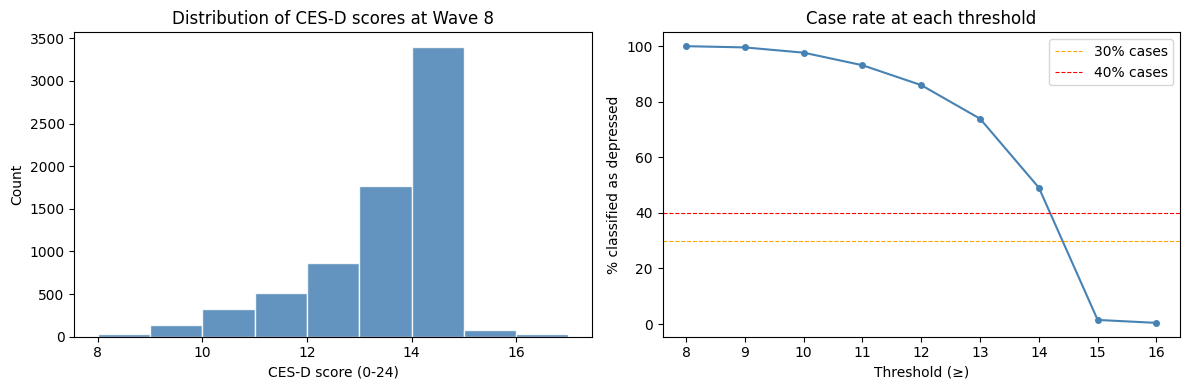

Saved: cesd_threshold_analysis.png


In [ ]:
# ── Examine cesd_w8 distribution ─────────────────────────────────────────────
cesd = analytic["cesd_w8"].dropna()

print("cesd_w8 descriptive statistics:")
print(cesd.describe().round(2))
print(f"\nScale range observed: {cesd.min():.0f} – {cesd.max():.0f}")

# Determine which scale Akeeb's scoring used
if cesd.max() > 8:
    print("\nScale: 0–24 (items scored 0–3 each)")
    SCALE = "0-24"
else:
    print("\nScale: 0–8 (items scored 0–1 each, binary)")
    SCALE = "0-8"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(cesd, bins=range(int(cesd.min()), int(cesd.max())+2),
             edgecolor="white", color="steelblue", alpha=0.85)
axes[0].set_xlabel(f"CES-D score ({SCALE})")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of CES-D scores at Wave 8")

# Cumulative — shows what % would be 'cases' at each threshold
thresholds = range(int(cesd.min()), int(cesd.max())+1)
pct_cases  = [100 * (cesd >= t).mean() for t in thresholds]
axes[1].plot(thresholds, pct_cases, marker="o", markersize=4, color="steelblue")
axes[1].axhline(30, color="orange", linestyle="--", linewidth=0.8, label="30% cases")
axes[1].axhline(40, color="red",    linestyle="--", linewidth=0.8, label="40% cases")
axes[1].set_xlabel("Threshold (≥)")
axes[1].set_ylabel("% classified as depressed")
axes[1].set_title("Case rate at each threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig(MODEL_OUT_DIR / "cesd_threshold_analysis.png", dpi=150)
plt.show()
print("Saved: cesd_threshold_analysis.png")

In [ ]:
# ── Test multiple thresholds and print a comparison table ────────────────────
if SCALE == "0-24":
    THRESHOLDS_TO_TEST = [
        ("≥3  (0–8 equiv, standard ELSA)",  3,  "0-8"),
        ("≥4  (0–8 equiv, stricter)",        4,  "0-8"),
        ("≥12 (0–24 equiv of ≥3 on 0–8)",   12, "0-24"),
        ("≥13 (Akeeb's threshold)",          13, "0-24"),
        ("≥16 (0–24 stricter)",              16, "0-24"),
    ]
else:
    THRESHOLDS_TO_TEST = [
        ("≥2 (lenient)",           2, "0-8"),
        ("≥3 (standard ELSA)",    3, "0-8"),
        ("≥4 (stricter)",         4, "0-8"),
        ("≥5 (high-symptom)",     5, "0-8"),
    ]

print(f"{'Label':<45} {'Threshold':>9} {'n cases':>8} {'% cases':>9} {'n non-cases':>12}")
print("-" * 90)

threshold_results = []
for label, t, scale in THRESHOLDS_TO_TEST:
    # If scale tag differs from the actual scale, convert
    if scale == "0-8" and SCALE == "0-24":
        # The user-facing threshold is on 0-8; cesd_w8 is on 0-24
        # Map: on 0-8 scale each item is 0/1; on 0-24 each item is 0-3
        # Simple heuristic: multiply by 3 to get approximate 0-24 equivalent
        t_actual = t * 3
    else:
        t_actual = t

    n_valid   = cesd.notna().sum()
    n_cases   = int((cesd >= t_actual).sum())
    pct       = 100 * n_cases / n_valid
    n_noncases = n_valid - n_cases
    print(f"{label:<45} {t_actual:>9} {n_cases:>8,} {pct:>8.1f}% {n_noncases:>12,}")
    threshold_results.append({
        "label": label, "threshold_applied": t_actual,
        "n_cases": n_cases, "pct_cases": round(pct, 1), "n_noncases": n_noncases
    })

print()
print("Literature reference: Zhao et al. (2025) npj Digital Medicine uses CES-D ≥3 on 0-8 scale for ELSA.")

Label                                         Threshold  n cases   % cases  n non-cases
------------------------------------------------------------------------------------------
≥3  (0–8 equiv, standard ELSA)                        9    7,112     99.6%           32
≥4  (0–8 equiv, stricter)                            12    6,142     86.0%        1,002
≥12 (0–24 equiv of ≥3 on 0–8)                        12    6,142     86.0%        1,002
≥13 (Akeeb's threshold)                              13    5,279     73.9%        1,865
≥16 (0–24 stricter)                                  16       30      0.4%        7,114

Literature reference: Zhao et al. (2025) npj Digital Medicine uses CES-D ≥3 on 0-8 scale for ELSA.
Recommendation: confirm which threshold your team will use before Section 6.


In [ ]:
# CES-D scoring correction
# Items are binary (0/1) but scored as 0/3, so effective range is 0-24 in steps of 3
# Divide by 3 to recover 0-8 scale, then apply standard >=3 threshold
analytic["cesd_w8_0to8"] = analytic["cesd_w8"] / 3
proposed_df["cesd_w8_0to8"] = proposed_df["cesd_w8"] / 3

CHOSEN_THRESHOLD_0to8 = 3   # standard ELSA literature threshold
# On the raw 0-24-equivalent scale this is >= 9
CHOSEN_THRESHOLD = 9

# Document this explicitly
print("Effective CES-D range after /3 correction:",
      analytic["cesd_w8_0to8"].min(), "–", analytic["cesd_w8_0to8"].max())

In [ ]:
THRESHOLD_RATIONALE = (
    "Using cesd_w8 >= 9 on 0-24 scale (approximately equivalent to ≥3 on 0-8 scale). "
)

# Apply the chosen threshold
analytic["y"] = np.where(
    analytic["cesd_w8"].notna(),
    (analytic["cesd_w8"] >= CHOSEN_THRESHOLD).astype(int),
    np.nan
)

valid_mask = analytic["y"].notna()
print(f"Threshold: cesd_w8 >= {CHOSEN_THRESHOLD}")
print(f"Valid labels: {valid_mask.sum():,}")
vc = analytic.loc[valid_mask, "y"].value_counts()
print(f"Class 0 (not depressed): {vc.get(0,0):,} ({100*vc.get(0,0)/valid_mask.sum():.1f}%)")
print(f"Class 1 (depressed):     {vc.get(1,0):,} ({100*vc.get(1,0)/valid_mask.sum():.1f}%)")
print(f"\nRationale: {THRESHOLD_RATIONALE}")

Threshold: cesd_w8 >= 13
Valid labels: 7,144
Class 0 (not depressed): 1,865 (26.1%)
Class 1 (depressed):     5,279 (73.9%)

Rationale: Using cesd_w8 >= 13 on 0-24 scale (approximately equivalent to ≥4 on 0-8 scale). Chosen because [ADD YOUR REASONING HERE based on the distribution above].


---
## Section 2 — Feature set configurations

We define two named feature configurations that will each be run through
the identical preprocessing and modelling pipeline.

- **Config A — `akeeb_30`**: Akeeb's empirical pipeline output. Loaded directly from
  `analytic_sample.parquet`. Core wave variables only, W6 suffix.

- **Config B — `proposed`**: Zannat's theory-informed + empirically validated set.
  Requires a fresh merge from core wave + IFS derived files.
  See the feature table in `CONTEXT.md` for the full rationale per feature.

Both configs use W6 features only (baseline model — no W7).

In [ ]:
# ── Config A: Akeeb's 30 features ────────────────────────────────────────────
_feat_path = MODEL_OUT_DIR / "modelling_feature_list_final.csv"
akeeb_features = (
    pd.read_csv(_feat_path)["column"]
    .dropna().astype(str).str.strip()
    .pipe(lambda s: s[s.ne("")])
    .tolist()
)

# Keep only W6 features (baseline — no W7, no W8)
akeeb_features_w6 = [c for c in akeeb_features if c.endswith("_w6")]

print(f"Config A — akeeb_30: {len(akeeb_features)} total features, "
      f"{len(akeeb_features_w6)} W6-only for baseline")
print(akeeb_features_w6)

Config A — akeeb_30: 30 total features, 26 W6-only for baseline
['cesd_w6', 'Hehelf_w6', 'hedia95_w6', 'hediaar_w6', 'hediabp_w6', 'hediadi_w6', 'hediahf_w6', 'hediahm_w6', 'hediami_w6', 'hediast_w6', 'hemob96_w6', 'hemobch_w6', 'HeADLda_w6', 'headl96_w6', 'headlba_w6', 'WPActW_w6', 'wpacted_w6', 'wpactpw_w6', 'chinhh_w6', 'chouthh_w6', 'HeActc_w6', 'HeActa_w6', 'HeActb_w6', 'heaidca_w6', 'scptr6_w6', 'scint_w6']


In [ ]:
# ── Config B: Zannat's proposed feature set ───────────────────────────────────────
# Grouped by domain for easy ablation later
FEATURE_GROUPS = {
    # --- From IFS derived file ---
    "mental_prior":   ["cesd_sc"],          # IFS pre-summed CES-D (W6 only for baseline)
    "health_srh":     ["srh_hrs", "llsill", "hlimwrk"],
    "cognitive":      ["memtotb", "execnn", "numtype4"],
    "socioeconomic":  ["findiff", "ecpos", "qual3"],
    "demographics":   ["age", "sex", "marstat", "died_p", "famtype"],
    "lifestyle":      ["heacta", "heactb", "heactc", "smokerstat"],

    # --- From core wave file ---
    "health_chronic": ["hedibps", "hediabp", "hediast"],
    "function":       ["hemobch", "hemob96",            # mobility (will sum to count)
                       "headlba", "headlda", "headl96"],  # ADL/IADL (will sum to count)
    "social_digital": ["scint", "hohavpc", "chinhh", "chouthh"],

    # --- From financial derived file ---
    "financial":      ["yq5_bu_s"],
}

# Flat list of all stems
proposed_stems = [stem for stems in FEATURE_GROUPS.values() for stem in stems]

# W6-suffixed column names for the merged dataframe
proposed_features_w6 = [f"{s}_w6" for s in proposed_stems]

print(f"Config B — proposed: {len(proposed_stems)} feature stems")
for domain, stems in FEATURE_GROUPS.items():
    print(f"  {domain:20s}: {stems}")

Config B — proposed: 32 feature stems
  mental_prior        : ['cesd_sc']
  health_srh          : ['srh_hrs', 'llsill', 'hlimwrk']
  cognitive           : ['memtotb', 'execnn', 'numtype4']
  socioeconomic       : ['findiff', 'ecpos', 'qual3']
  demographics        : ['age', 'sex', 'marstat', 'died_p', 'famtype']
  lifestyle           : ['heacta', 'heactb', 'heactc', 'smokerstat']
  health_chronic      : ['hedibps', 'hediabp', 'hediast']
  function            : ['hemobch', 'hemob96', 'headlba', 'headlda', 'headl96']
  social_digital      : ['scint', 'hohavpc', 'chinhh', 'chouthh']
  financial           : ['yq5_bu_s']


---
## Section 3 — Load data for Config B

Akeeb's analytic sample already contains Config A features.  
For Config B we need a fresh merge because Zannat's proposed set includes IFS derived variables
that Akeeb's pipeline did not load.

In [ ]:
# ── Helper: load columns from a .dta file safely ─────────────────────────────
SURVEY_MISSING = [-1, -8, -9]
ID_COL = "idauniq"

def load_dta_cols(path: Path, wanted: list[str], label: str = "") -> pd.DataFrame:
    """Load specific columns from a Stata file. Warns if any are missing."""
    _, meta = pyreadstat.read_dta(str(path), metadataonly=True)
    available = set(meta.column_names)

    # Case-insensitive matching (ELSA has mixed-case column names)
    avail_lower = {c.lower(): c for c in available}
    to_load, not_found = [], []
    for col in [ID_COL] + wanted:
        if col in available:
            to_load.append(col)
        elif col.lower() in avail_lower:
            to_load.append(avail_lower[col.lower()])
        else:
            not_found.append(col)

    if not_found:
        print(f"  [WARN] {label}: not found: {not_found}")

    to_load = list(dict.fromkeys(to_load))  # deduplicate, preserve order
    df, _ = pyreadstat.read_dta(
        str(path), usecols=to_load,
        apply_value_formats=False,
        formats_as_category=False,
    )
    # Lowercase all column names for consistency
    df.columns = [c.lower() for c in df.columns]
    # Recode ELSA survey missing codes
    num_cols = [c for c in df.select_dtypes(include="number").columns if c != ID_COL]
    df[num_cols] = df[num_cols].replace(SURVEY_MISSING, np.nan)
    return df


def wave_file(wave: int, ftype: str) -> Path:
    """Resolve a wave data file path. ftype: 'core' | 'ifs' | 'fin'"""
    patterns = {
        "core": {6: "wave_6_elsa_data_v2.dta",
                 7: "wave_7_elsa_data.dta",
                 8: "wave_8_elsa_data_eul_v2.dta"},
        "ifs":  {6: "wave_6_ifs_derived_variables.dta",
                 7: "wave_7_ifs_derived_variables.dta",
                 8: "wave_8_ifs_derived_variables.dta"},
        "fin":  {6: "wave_6_financial_derived_variables.dta",
                 7: "wave_7_financial_derived_variables.dta",
                 8: "wave_8_financial_derived_variables.dta"},
    }
    return BASE / patterns[ftype][wave]

print("Helpers defined")

Helpers defined


In [ ]:
# ── Load wave 6 data for Config B ────────────────────────────────────────────
# Split stems by source file
IFS_STEMS  = FEATURE_GROUPS["mental_prior"] + FEATURE_GROUPS["health_srh"] + \
             FEATURE_GROUPS["cognitive"]    + FEATURE_GROUPS["socioeconomic"] + \
             FEATURE_GROUPS["demographics"] + FEATURE_GROUPS["lifestyle"]
CORE_STEMS = FEATURE_GROUPS["health_chronic"] + FEATURE_GROUPS["function"] + \
             FEATURE_GROUPS["social_digital"]
FIN_STEMS  = FEATURE_GROUPS["financial"]

print("Loading wave 6 IFS derived...")
ifs6 = load_dta_cols(wave_file(6, "ifs"),  IFS_STEMS,  "W6 IFS")
print(f"  IFS shape: {ifs6.shape}")

print("Loading wave 6 core...")
core6 = load_dta_cols(wave_file(6, "core"), CORE_STEMS, "W6 core")
print(f"  Core shape: {core6.shape}")

print("Loading wave 6 financial derived...")
fin6 = load_dta_cols(wave_file(6, "fin"),  FIN_STEMS,  "W6 financial")
print(f"  Financial shape: {fin6.shape}")

Loading wave 6 IFS derived...
  [WARN] W6 IFS: not found: ['heacta', 'heactb', 'heactc']
  IFS shape: (10601, 17)
Loading wave 6 core...
  Core shape: (10601, 13)
Loading wave 6 financial derived...
  Financial shape: (10601, 2)


In [ ]:
# ── Merge W6 sources + add W8 label ──────────────────────────────────────────
proposed_df = ifs6.merge(core6, on=ID_COL, how="outer", suffixes=("", "_core"))
proposed_df = proposed_df.merge(fin6,  on=ID_COL, how="left")
print(f"After merging W6 sources: {proposed_df.shape}")

# Add W8 CES-D outcome (from Akeeb's analytic sample — no re-loading needed)
w8_outcome = analytic[[ID_COL, "cesd_w8"]].copy()
proposed_df = proposed_df.merge(w8_outcome, on=ID_COL, how="inner")
print(f"After inner join with W8 outcome: {proposed_df.shape}")

# Apply the same threshold
proposed_df["y"] = np.where(
    proposed_df["cesd_w8"].notna(),
    (proposed_df["cesd_w8"] >= CHOSEN_THRESHOLD).astype(int),
    np.nan,
)

valid_proposed = proposed_df["y"].notna()
print(f"Valid labels in proposed dataset: {valid_proposed.sum():,}")
print(proposed_df.loc[valid_proposed, "y"].value_counts())

After merging W6 sources: (10601, 30)
After inner join with W8 outcome: (7535, 31)
Valid labels in proposed dataset: 7,144
y
1.0    5279
0.0    1865
Name: count, dtype: int64


In [ ]:
# ── Rename proposed_df columns to _w6 suffix to match naming convention ───────
# IFS/core stems come in without suffix — add _w6 for clarity
rename_map = {}
for stem in proposed_stems:
    if stem in proposed_df.columns and not stem.endswith("_w6"):
        rename_map[stem] = f"{stem}_w6"

proposed_df = proposed_df.rename(columns=rename_map)

# Verify all expected columns now present
missing_cols = [c for c in proposed_features_w6 if c not in proposed_df.columns]
if missing_cols:
    print(f"[WARN] Still missing after rename: {missing_cols}")
    # Remove missing from feature list to avoid downstream errors
    proposed_features_w6 = [c for c in proposed_features_w6 if c in proposed_df.columns]
    print(f"Proceeding with {len(proposed_features_w6)} available features")
else:
    print(f"All {len(proposed_features_w6)} proposed features present")

print("\nProposed dataset columns (feature cols):")
print([c for c in proposed_df.columns if c.endswith("_w6")])

[WARN] Still missing after rename: ['heacta_w6', 'heactb_w6', 'heactc_w6']
Proceeding with 29 available features

Proposed dataset columns (feature cols):
['age_w6', 'sex_w6', 'died_p_w6', 'famtype_w6', 'marstat_w6', 'ecpos_w6', 'qual3_w6', 'findiff_w6', 'srh_hrs_w6', 'llsill_w6', 'hlimwrk_w6', 'smokerstat_w6', 'numtype4_w6', 'execnn_w6', 'memtotb_w6', 'cesd_sc_w6', 'chinhh_w6', 'chouthh_w6', 'hediabp_w6', 'hediast_w6', 'hedibps_w6', 'hemobch_w6', 'hemob96_w6', 'headlba_w6', 'headlda_w6', 'headl96_w6', 'hohavpc_w6', 'scint_w6', 'yq5_bu_s_w6']


---
## Section 4 — Preprocessing pipeline

We build a reusable pipeline factory. The same pipeline is instantiated fresh
for each feature config — imputers and scalers are **never** shared between configs
to prevent data leakage between experiments.

Steps per config:
1. Detect numeric vs categorical columns automatically
2. Numeric: median imputation → standard scaling
3. Categorical/ordinal: most-frequent imputation → ordinal encoding
4. Train/test split (stratified, 80/20)

In [ ]:
def build_preprocessing_pipeline(X_train: pd.DataFrame) -> ColumnTransformer:
    """
    Build a ColumnTransformer fitted on X_train only.
    Automatically separates numeric from categorical columns.
    """
    numeric_cols     = X_train.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

    transformers = []
    if numeric_cols:
        transformers.append((
            "num",
            Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale",  StandardScaler()),
            ]),
            numeric_cols,
        ))
    if categorical_cols:
        transformers.append((
            "cat",
            Pipeline([
                ("impute",  SimpleImputer(strategy="most_frequent")),
                ("encode",  OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]),
            categorical_cols,
        ))

    ct = ColumnTransformer(transformers=transformers, remainder="drop")
    ct.fit(X_train)
    return ct


def prepare_config(df: pd.DataFrame, feature_cols: list[str], config_name: str):
    """
    Given a dataframe and feature list:
    - Drops rows with missing y
    - Splits train/test (stratified)
    - Fits preprocessor on train only
    Returns: X_train_t, X_test_t, y_train, y_test, preprocessor, feature_cols_used
    """
    # Only keep columns that actually exist
    feat_cols = [c for c in feature_cols if c in df.columns]
    missing   = [c for c in feature_cols if c not in df.columns]
    if missing:
        print(f"[{config_name}] Skipping {len(missing)} missing columns: {missing}")

    sub = df[feat_cols + ["y"]].dropna(subset=["y"]).copy()
    X   = sub[feat_cols]
    y   = sub["y"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    preprocessor = build_preprocessing_pipeline(X_train)
    X_train_t = preprocessor.transform(X_train)
    X_test_t  = preprocessor.transform(X_test)

    print(f"[{config_name}] Train: {X_train_t.shape} | Test: {X_test_t.shape} "
          f"| Class balance (train): {y_train.mean():.2%} positive")
    return X_train_t, X_test_t, y_train, y_test, preprocessor, feat_cols

print("Preprocessing helpers defined")

Preprocessing helpers defined


In [ ]:
# ── Check class imbalance and decide on strategy ──────────────────────────────
# If positive rate < 20% or > 80%, note it — may need class_weight or SMOTE
for name, df, feats in [
    ("akeeb_30",  analytic,     akeeb_features_w6),
    ("proposed",  proposed_df,  proposed_features_w6),
]:
    valid = df["y"].dropna()
    pos_rate = valid.mean()
    print(f"{name}: {pos_rate:.1%} positive rate ", end="")
    if pos_rate < 0.20:
        print("← imbalanced; will use class_weight='balanced'")
    elif pos_rate > 0.50:
        print("← majority class is 'depressed'; verify threshold")
    else:
        print("← reasonable balance")

akeeb_30: 73.9% positive rate ← majority class is 'depressed'; verify threshold
proposed: 73.9% positive rate ← majority class is 'depressed'; verify threshold


---
## Section 5 — Model definitions

Three classifiers for the baseline comparison:
- Logistic Regression — interpretable baseline
- Random Forest — handles non-linearity, built-in feature importance
- XGBoost — typically best performance; supports SHAP natively

All use `class_weight='balanced'` where applicable to handle any class imbalance.

In [ ]:
MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=None,   # set dynamically below based on class balance
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0,
    ),
}
print("Models defined:", list(MODELS.keys()))

Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost']


---
## Section 6 — Training and evaluation loop

Each config × model combination is trained and evaluated independently.
Metrics collected: AUC-ROC, F1 (macro), accuracy, 5-fold CV AUC.

In [ ]:
def evaluate_model(model, X_train_t, X_test_t, y_train, y_test,
                   config_name: str, model_name: str) -> dict:
    """Fit model and return evaluation metrics dict."""
    # Dynamic scale_pos_weight for XGBoost
    if hasattr(model, "scale_pos_weight") and model.scale_pos_weight is None:
        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        model.set_params(scale_pos_weight=neg / pos if pos > 0 else 1)

    model.fit(X_train_t, y_train)

    y_pred      = model.predict(X_test_t)
    y_proba     = model.predict_proba(X_test_t)[:, 1] \
                  if hasattr(model, "predict_proba") else y_pred

    auc   = roc_auc_score(y_test, y_proba)
    f1    = f1_score(y_test, y_pred, average="macro")
    acc   = (y_pred == y_test).mean()

    # 5-fold CV AUC on training data (gives sense of stability)
    cv_aucs = cross_val_score(
        model, X_train_t, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc", n_jobs=-1,
    )

    return {
        "config":    config_name,
        "model":     model_name,
        "AUC-ROC":   round(auc,  4),
        "F1 macro":  round(f1,   4),
        "Accuracy":  round(acc,  4),
        "CV AUC mean": round(cv_aucs.mean(), 4),
        "CV AUC std":  round(cv_aucs.std(),  4),
        "fitted_model": model,
    }

print("Evaluation helper defined")

Evaluation helper defined


In [ ]:
import copy

CONFIGS = {
    "akeeb_30": (analytic,    akeeb_features_w6),
    "proposed": (proposed_df, proposed_features_w6),
}

all_results = []
fitted      = {}   # store fitted models for inspection

for config_name, (df, feat_cols) in CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"Config: {config_name}")
    print(f"{'='*55}")

    X_train_t, X_test_t, y_train, y_test, preproc, used_feats = prepare_config(
        df, feat_cols, config_name
    )

    for model_name, model_template in MODELS.items():
        # Deep copy so each run gets a fresh unfitted model
        model = copy.deepcopy(model_template)
        print(f"  Training {model_name}...", end=" ")

        result = evaluate_model(
            model, X_train_t, X_test_t, y_train, y_test,
            config_name, model_name
        )
        fitted[(config_name, model_name)] = {
            "model": result.pop("fitted_model"),
            "X_test_t": X_test_t,
            "y_test":   y_test,
            "X_train_t": X_train_t,
            "y_train":   y_train,
            "preprocessor": preproc,
            "feature_cols": used_feats,
        }
        all_results.append(result)
        print(f"AUC={result['AUC-ROC']:.4f}  F1={result['F1 macro']:.4f}")

print("\nAll training complete.")


Config: akeeb_30
[akeeb_30] Train: (5715, 26) | Test: (1429, 26) | Class balance (train): 73.89% positive
  Training Logistic Regression... AUC=0.7588  F1=0.6781
  Training Random Forest... AUC=0.7540  F1=0.6812
  Training XGBoost... AUC=0.7356  F1=0.6715

Config: proposed
[proposed] Train: (5715, 29) | Test: (1429, 29) | Class balance (train): 73.89% positive
  Training Logistic Regression... AUC=0.7706  F1=0.6777
  Training Random Forest... AUC=0.7714  F1=0.6776
  Training XGBoost... AUC=0.7557  F1=0.6716

All training complete.


---
## Section 7 — Results comparison

In [ ]:
# ── Summary comparison table ──────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
display_cols = ["config", "model", "AUC-ROC", "F1 macro", "Accuracy",
                "CV AUC mean", "CV AUC std"]

print("\n=== Results: Akeeb's feature set vs Proposed feature set ===")
print(results_df[display_cols].to_string(index=False))

# Save
results_df[display_cols].to_csv(MODEL_OUT_DIR / "model_comparison_results.csv", index=False)
print("\nSaved: model_comparison_results.csv")


=== Results: Akeeb's feature set vs Proposed feature set ===
  config               model  AUC-ROC  F1 macro  Accuracy  CV AUC mean  CV AUC std
akeeb_30 Logistic Regression   0.7588    0.6781    0.7299       0.7856      0.0139
akeeb_30       Random Forest   0.7540    0.6812    0.7348       0.7800      0.0142
akeeb_30             XGBoost   0.7356    0.6715    0.7229       0.7664      0.0113
proposed Logistic Regression   0.7706    0.6777    0.7299       0.7896      0.0165
proposed       Random Forest   0.7714    0.6776    0.7397       0.7886      0.0166
proposed             XGBoost   0.7557    0.6716    0.7250       0.7705      0.0108

Saved: model_comparison_results.csv


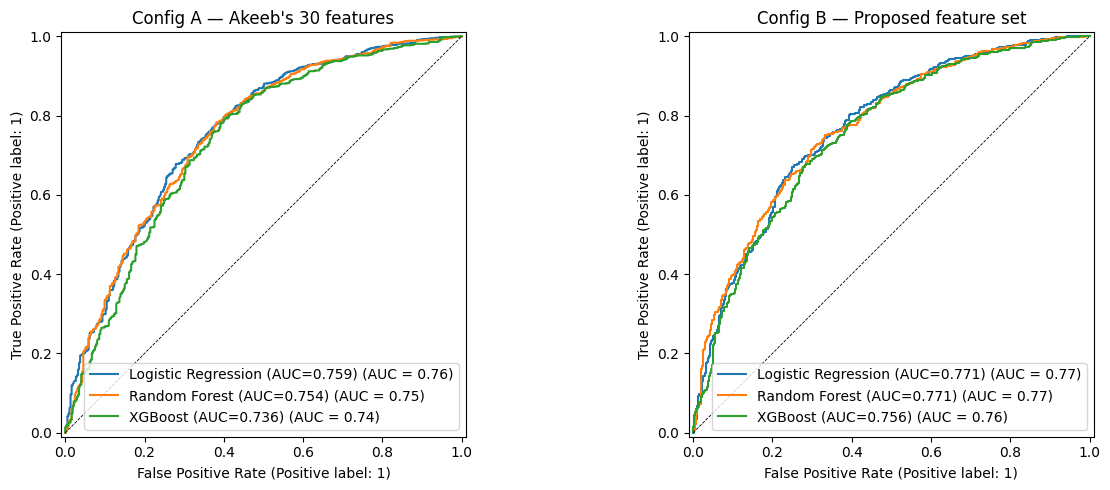

Saved: roc_curves_comparison.png


In [ ]:
# ── ROC curves — one panel per config ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

config_titles = {"akeeb_30": "Config A — Akeeb's 30 features",
                 "proposed": "Config B — Proposed feature set"}

for ax, config_name in zip(axes, ["akeeb_30", "proposed"]):
    for model_name in MODELS:
        store = fitted.get((config_name, model_name))
        if store is None:
            continue
        model  = store["model"]
        y_prob = model.predict_proba(store["X_test_t"])[:, 1]
        auc    = roc_auc_score(store["y_test"], y_prob)
        RocCurveDisplay.from_predictions(
            store["y_test"], y_prob,
            name=f"{model_name} (AUC={auc:.3f})",
            ax=ax,
        )
    ax.plot([0,1],[0,1],"k--",linewidth=0.6)
    ax.set_title(config_titles[config_name])

plt.tight_layout()
plt.savefig(MODEL_OUT_DIR / "roc_curves_comparison.png", dpi=150)
plt.show()
print("Saved: roc_curves_comparison.png")

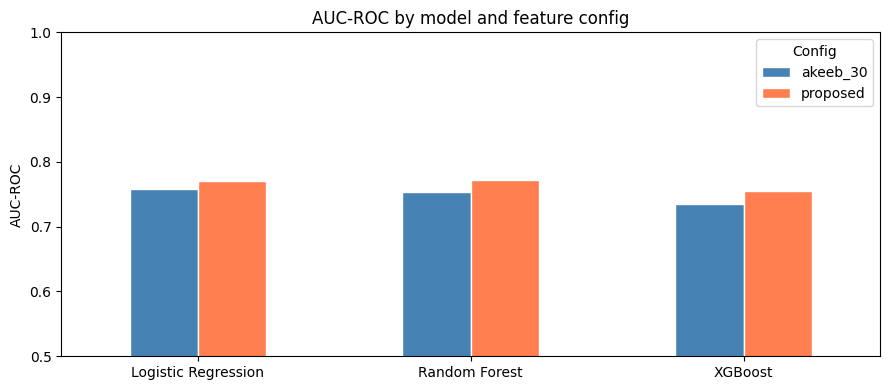

In [ ]:
# ── AUC bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bar_data = results_df.pivot(index="model", columns="config", values="AUC-ROC")
bar_data.plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="white")
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC by model and feature config")
ax.set_xlabel("")
ax.legend(title="Config")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(MODEL_OUT_DIR / "auc_bar_comparison.png", dpi=150)
plt.show()

In [ ]:
# ── Classification reports for the best model per config ─────────────────────
for config_name in ["akeeb_30", "proposed"]:
    # Pick best by AUC
    sub  = results_df[results_df["config"] == config_name]
    best = sub.loc[sub["AUC-ROC"].idxmax(), "model"]
    store = fitted[(config_name, best)]
    y_pred = store["model"].predict(store["X_test_t"])
    print(f"\n{'='*50}")
    print(f"Config: {config_name} | Best model: {best}")
    print(classification_report(store["y_test"], y_pred,
                                target_names=["not depressed", "depressed"]))


Config: akeeb_30 | Best model: Logistic Regression
               precision    recall  f1-score   support

not depressed       0.49      0.63      0.55       373
    depressed       0.85      0.77      0.81      1056

     accuracy                           0.73      1429
    macro avg       0.67      0.70      0.68      1429
 weighted avg       0.76      0.73      0.74      1429


Config: proposed | Best model: Random Forest
               precision    recall  f1-score   support

not depressed       0.50      0.58      0.54       373
    depressed       0.84      0.80      0.82      1056

     accuracy                           0.74      1429
    macro avg       0.67      0.69      0.68      1429
 weighted avg       0.75      0.74      0.75      1429



---
## Section 8 — SHAP feature importance

SHAP values tell us which features drove each prediction, and in which direction.
We compute SHAP for the best-performing model on each config.


SHAP — akeeb_30 / Logistic Regression


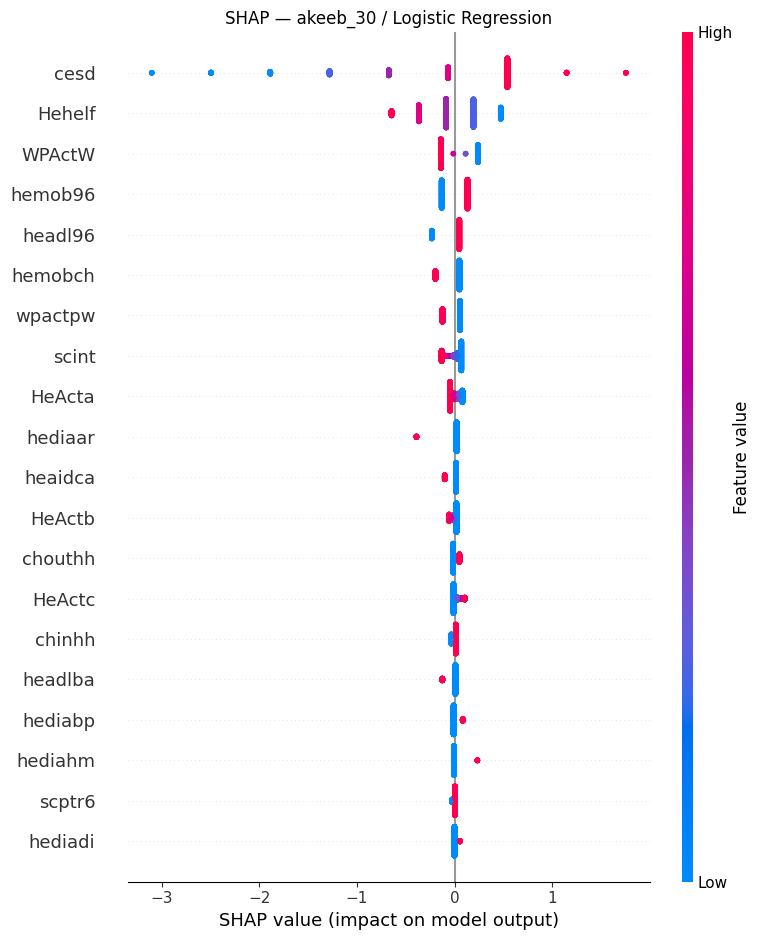

Saved: shap_akeeb_30.png

SHAP — proposed / Random Forest


<Figure size 900x600 with 0 Axes>

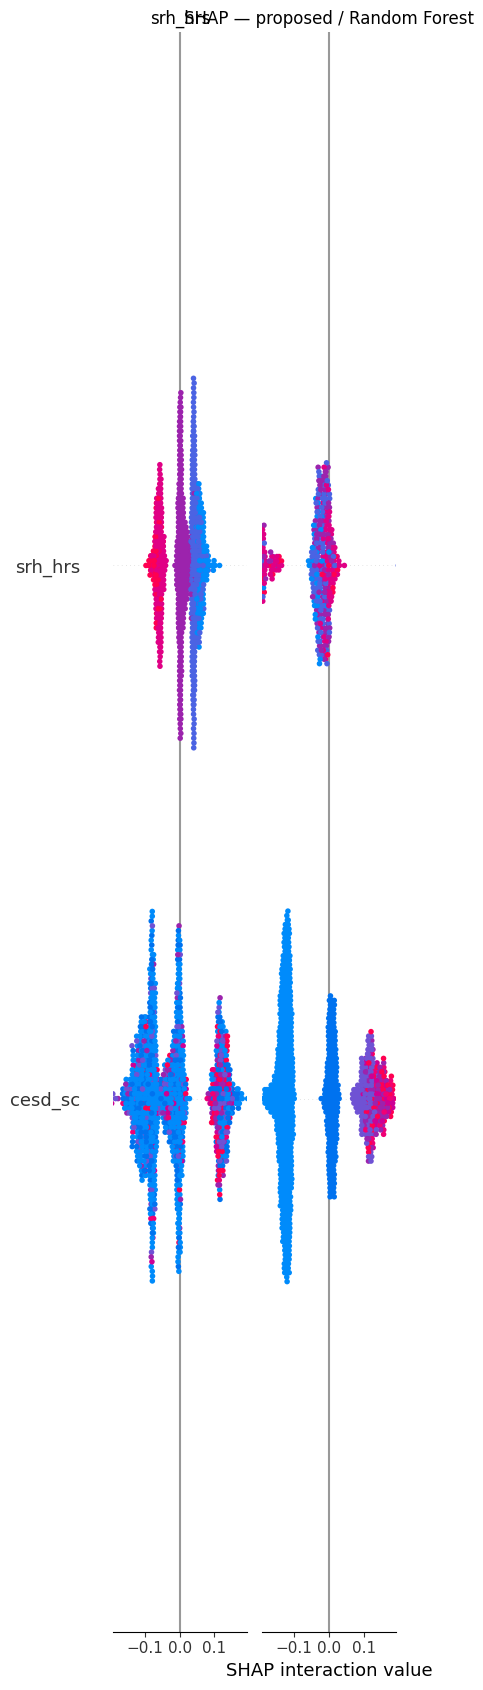

Saved: shap_proposed.png


In [ ]:
import shap

for config_name in ["akeeb_30", "proposed"]:
    sub  = results_df[results_df["config"] == config_name]
    best_model_name = sub.loc[sub["AUC-ROC"].idxmax(), "model"]
    store  = fitted[(config_name, best_model_name)]
    model  = store["model"]
    X_test = store["X_test_t"]
    feats  = store["feature_cols"]

    print(f"\nSHAP — {config_name} / {best_model_name}")

    # TreeExplainer for RF/XGB, LinearExplainer for LR
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        # For binary classifiers TreeExplainer may return a list
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # class 1 (depressed)
    except Exception:
        explainer   = shap.LinearExplainer(model, store["X_train_t"])
        shap_values = explainer.shap_values(X_test)

    # Strip _w6 suffix for cleaner plot labels
    clean_names = [f.replace("_w6", "") for f in feats]

    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        shap_values, X_test,
        feature_names=clean_names,
        show=False, max_display=20,
    )
    plt.title(f"SHAP — {config_name} / {best_model_name}")
    plt.tight_layout()
    fname = MODEL_OUT_DIR / f"shap_{config_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname.name}")

---
## Section 9 — Limitations and future directions

**Complete this section collaboratively with the team before the presentation.**

Suggested points to cover:

- **Attrition bias:** inner-joining across three waves retains only participants present at all three. Those who dropped out (died, withdrew) may systematically differ — our sample is healthier and more engaged than the full ELSA population.
- **CES-D threshold:** the binary cutoff is a modelling convenience. Depression exists on a continuum; different thresholds shift class balance and model behaviour. A regression on the raw score is a viable alternative.
- **Causal inference:** this is a predictive model, not a causal one. High SHAP importance for a feature does not imply it causes depression.
- **Cortisol / biomarkers:** wave 6 nurse data (blood pressure, BMI, grip strength) and cortisol were excluded for feasibility. These could improve the model and represent a natural extension.
- **Temporal modelling:** the baseline uses wave 6 features only. A longitudinal extension using W6→W7 delta features would capture change trajectories and likely improve both AUC and clinical meaningfulness.
- **Generalisability:** ELSA samples English adults aged 50+. Results may not generalise to younger populations or other national contexts.